In [1]:
#%pip install numpy --break-system-packages

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma

### 1. Nosso objetivo é realizar a amostragem de Gibbs na distribuição posterior de um modelo de mistura Normal. Assumimos que as observações $Y = \{Y_1, \ldots, Y_N\}$ são independentes e cada uma é distribuida de acordo com a densidade

### $$f(x) = \sum_{k=1}^K p_k \varphi(x; \mu_k, \sigma_k^2)$$

### onde $\varphi$ é uma densidade Gaussiana para $\mu \in \mathbb{R},\ \sigma^2 \in \mathbb{R}^+$,

### $$\varphi(x; \mu, \sigma^2) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left\{ - \frac{1}{2 \sigma^2} (x - \mu)^2\right\}.$$

### Seja $p = (p_1, \ldots, p_K)$ o vetor de pesos, $\mu = (\mu_1, \ldots, \mu_K)$ o vetor de medias, $\sigma^2 = (\sigma_1^2, \ldots, \sigma_K^2)$ o vetor de variancias.

### Introduza um vetor aleatorio $Z = \{Z_1, \ldots, Z_N\}$ com $Z_i$ tomando valores em $\{1, \ldots, K\}$ e tal que

### $$P(Z = z \mid p) = \prod_{i=1}^N P(Z_i = z_i \mid p) = \prod_{i=1}^N p_{z_i},$$

### i.e. $P(Z_i = z_i \mid p) = p_{z_i}\ \forall k \in I_K$ e $i \in I_N$. Então introduza variaveis $X = \{X_1, \ldots, X_N\}$ tal que

### $$\forall i \in I_N \quad X_i \mid Z_i = z_i,p,\mu,\sigma^2 \quad \sim \quad \mathcal{N}(\mu_{z_i}, \sigma_{z_i}^2).$$

### Verifique que $X$ dado $p, \mu, \sigma^2$ tem a mesma distribuição de Y.

In [3]:
K = 2
p_0 = np.full(K, 1 / K)
mu_0 = np.linspace(-K, K, K)
sigma2_0 = np.ones(K)
N = 1000

z = np.random.choice(np.arange(1, K + 1), size=N, p=p_0)

y = np.concatenate([
    np.random.normal(loc=mu_0[i - 1], scale=np.sqrt(sigma2_0[i - 1]), size=np.sum(z == i))
    for i in range(1, K + 1)
])

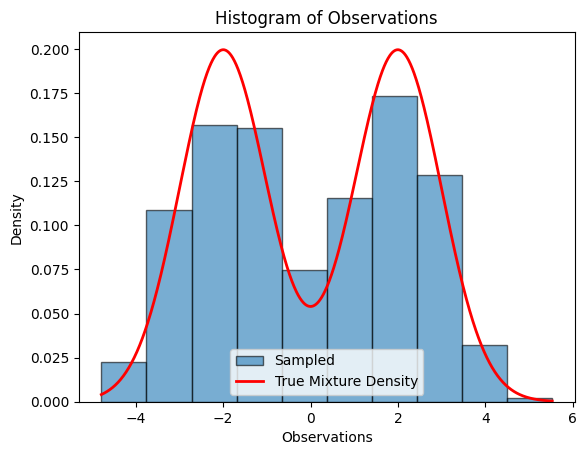

In [4]:
df = pd.DataFrame({'observations': y})
plt.hist(df['observations'], bins=10, density=True, alpha=0.6, edgecolor='black', label="Sampled")

y_vals = np.linspace(min(y), max(y), 1000)
mixture_density = sum(p_0[k] * stats.norm.pdf(y_vals, mu_0[k], sigma2_0[k]) for k in range(K))
plt.plot(y_vals, mixture_density, 'r-', lw=2, label="True Mixture Density")

plt.xlabel('Observations')
plt.ylabel('Density')
plt.title('Histogram of Observations')
plt.legend()
plt.show()


### 2. Assumindo distribuições a priori de $p,\ \mu,\ \sigma^2$. Primeiro os pesos seguem uma distribuição de Dirichlet com parametros $\gamma_1, \ldots, \gamma_K$:

### $$\pi(p) \propto \prod_{i=1}^K p_i^{\gamma_k-1}.$$

### Então todas as médias seguem a mesma distribuição normal com parâmetros $(m, \tau^2)$

### $$\pi(\mu_k) \propto \exp\left\{ - \frac{1}{2\tau^2} (\mu_k - m)^2 \right\},\ \forall k \in I_K.$$

### Finalmente as variancias seguem uma distribuição Gamma inversa com parametros $(\alpha, \beta)$:

### $$\pi(\sigma_k^2) \propto (\sigma_k^2)^{-\alpha - 1} \exp\{- \beta \sigma_k^{-2}\},\ \forall k \in I_K.$$

### Derive a distribuição condicional de $Z$ dado $X, p, \mu, \sigma^2$ e descreva como amostrar.

Queremos agora fazer uma amostragem da distribuição posterior dos parâmetros dado o conjunto de dados. Vamos configurar os “hiper” parâmetros à prior. Temos como prior para $p,\ \mu_k,\ \sigma_k^2$:

$$
\begin{align}
\pi(p) &\propto \prod_{i=1}^K p_i^{\gamma_k-1}, \\
\pi(\mu_k) &\propto \exp\left\{ - \frac{1}{2\tau^2} (\mu_k - m)^2 \right\},\ \forall k \in I_K, \\
\pi(\sigma_k^2) &\propto (\sigma_k^2)^{-\alpha - 1} \exp\{- \beta \sigma_k^{-2}\},\ \forall k \in I_K.
\end{align}
$$

In [5]:
# Choose hyper parameters
gamma = np.ones(K)

m = 0
tau = 1
alpha = 2
beta = 1

Precisamos de funções para amostrar as várias condicionais da distribuição posterior.

In [6]:
def zconditional(y, p, mu, sigma2):
    """Conditional distribution of z given the rest."""
    N = len(y)
    K = len(p)
    next_z = np.zeros(N, dtype=int)

    for i in range(N):
        prob = p * norm.pdf(y[i], loc=mu, scale=np.sqrt(sigma2))
        prob /= prob.sum()  # Normalize probabilities
        next_z[i] = np.random.choice(np.arange(K), p=prob)

    return next_z

### 3. Derive a distribuição condicional de $p$ dado $X, Z, \mu, \sigma^2$ e descreva como amostrar

In [7]:
def pconditional(y, z, mu, sigma2, gamma_prior):
    """Conditional distribution of p given the rest."""
    K = len(mu)
    n_by_cluster = np.array([np.sum(z == j) for j in range(K)])
    next_p = gamma.rvs(a=gamma_prior + n_by_cluster, scale=1)
    return next_p / next_p.sum()

### 4. Derive a distribuição condicional de $\mu$ dado $X, Z, p, \sigma^2$ e descreva como amostrar

In [8]:
def muconditional(y, z, p, sigma2, tau, m):
    """Conditional distribution of mu given the rest."""
    K = len(p)
    n_by_cluster = np.array([np.sum(z == j) for j in range(K)])
    sum_y_by_cluster = np.array([np.sum(y[z == j]) for j in range(K)])

    cond_mean = (m / tau**2 + sum_y_by_cluster / sigma2) / (1 / tau**2 + n_by_cluster / sigma2)
    cond_var = 1 / (1 / tau**2 + n_by_cluster / sigma2)
    
    next_mu = np.random.normal(loc=cond_mean, scale=np.sqrt(cond_var))
    return next_mu

### 5. Derive a distribuição condicional de $\sigma^2$ dado $X, Z, p, \mu$ e descreva como amostrar

In [9]:
def sigma2conditional(y, z, p, mu, alpha, beta):
    """Conditional distribution of sigma^2 given the rest."""
    K = len(p)
    n_by_cluster = np.array([np.sum(z == j) for j in range(K)])
    sum_square_by_cluster = np.array([np.sum((y[z == j] - mu[j])**2) for j in range(K)])

    cond_shape = alpha + n_by_cluster / 2
    cond_rate = beta + sum_square_by_cluster / 2

    next_sigma2 = 1 / gamma.rvs(a=cond_shape, scale=1 / cond_rate)
    return next_sigma2